# Task 4

## Answer 4.a

First, import python packages.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define constants.

In [67]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load index data from excel.

In [68]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [69]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute forward 10D log-return.

In [70]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-11)) - np.log(data['^GSPC'].shift(-1))
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.022494
2015-10-16,2033.109985,4438.620117,0.004560,0.034027
2015-10-19,2033.660034,4462.069824,0.000271,0.038173
2015-10-20,2030.770020,4438.180176,-0.001422,0.040464
2015-10-21,2018.939941,4413.520020,-0.005842,0.022841
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Only keep the rows between [2025-01-01, 2026-01-15]. 

In [71]:
data = data.loc['2025-01-01':'2026-01-15'].copy()
total_count = data.shape[0]
print(f'Total number of observations: {total_count}')

Total number of observations: 260


Compute overall variance.

In [72]:
# 计算总体方差
overall_variance = data['LogReturn'].var()
print(f'Overall variance of log returns: {overall_variance:.6f}')

Overall variance of log returns: 0.000133


Use overall variance as variance of the first day and compute variance of other days.

$$\sigma_{t+1|t}^2 = \lambda\sigma_{t|t-1}^2 + (1-\lambda)r_t^2$$

In [73]:
param = 0.72

data.loc[data.index[0], 'variance'] = overall_variance

for i in range(1, len(data)):
    variance = param * data.loc[data.index[i - 1], 'variance'] + (1 - param) * data.loc[data.index[i - 1], 'LogReturn']**2
    data.loc[data.index[i], 'variance'] = variance

data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance
Date,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000097
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000114
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000091
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000100
...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,0.000191,0.000018
2026-01-12,6977.270020,25787.660156,0.001576,0.002050,0.000024
2026-01-13,6963.740234,25741.949219,-0.001941,0.006104,0.000018


In [74]:
data['SD'] = np.sqrt(data['variance'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD
Date,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133,0.011545
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000097,0.009867
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000114,0.010675
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000091,0.009518
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000100,0.010007
...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,0.000191,0.000018,0.004205
2026-01-12,6977.270020,25787.660156,0.001576,0.002050,0.000024,0.004939
2026-01-13,6963.740234,25741.949219,-0.001941,0.006104,0.000018,0.004273


Compute VaR and Breach

In [75]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133,0.011545,-0.084930,0
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000097,0.009867,-0.072584,0
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000114,0.010675,-0.078534,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000091,0.009518,-0.070020,0
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000100,0.010007,-0.073616,0
...,...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,0.000191,0.000018,0.004205,-0.030931,0
2026-01-12,6977.270020,25787.660156,0.001576,0.002050,0.000024,0.004939,-0.036334,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.006104,0.000018,0.004273,-0.031435,0


Select the "breach" rows.

In [76]:
data_breach = data[data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 12


,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-02-13,6115.069824,22030.710938,0.010372,-0.044290,0.000027,0.005212,-0.038344,1
2025-02-14,6114.629883,22114.689453,-0.000072,-0.059043,0.000050,0.007049,-0.051854,1
2025-02-18,6129.580078,22164.609375,0.002442,-0.050319,0.000036,0.005981,-0.044001,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.063955,0.000027,0.005237,-0.038527,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.041239,0.000021,0.004618,-0.033972,1
2025-02-21,6013.129883,21614.080078,-0.017211,-0.063601,0.000021,0.004543,-0.033420,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.059764,0.000062,0.007865,-0.057863,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.054451,0.000045,0.006674,-0.049101,1
2025-03-20,5662.890137,19677.609375,-0.002187,-0.110613,0.000158,0.012585,-0.092582,1


In [77]:
print(f'Count of breaches: {breach_count}, totol count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 12, totol count: 260, breach percentage: 4.62%


So, the count of VaR beaches is 12, and the precentage is 4.62%.

---

## Answer 4.b

Here we present 2 plots: 
- the first is breaches
- the second is index level

In the first plot, we draw two lines:
- 10D VaR (Red)
- Forward 10D log return (Blue)

Also, we draw black crosses where return is blow VaR.

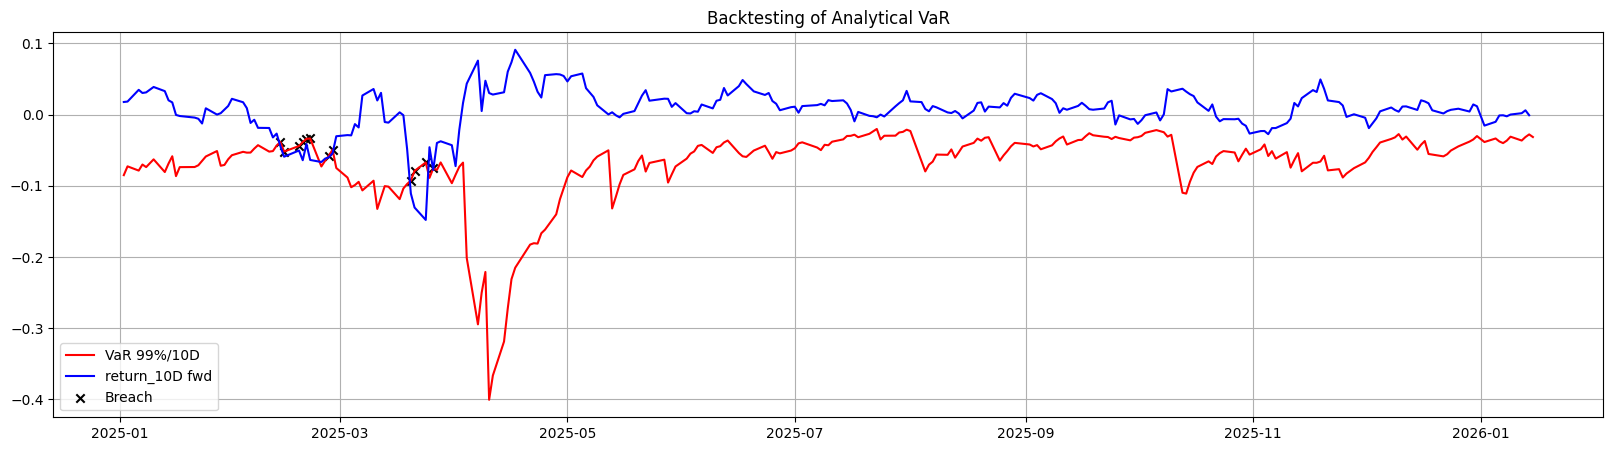

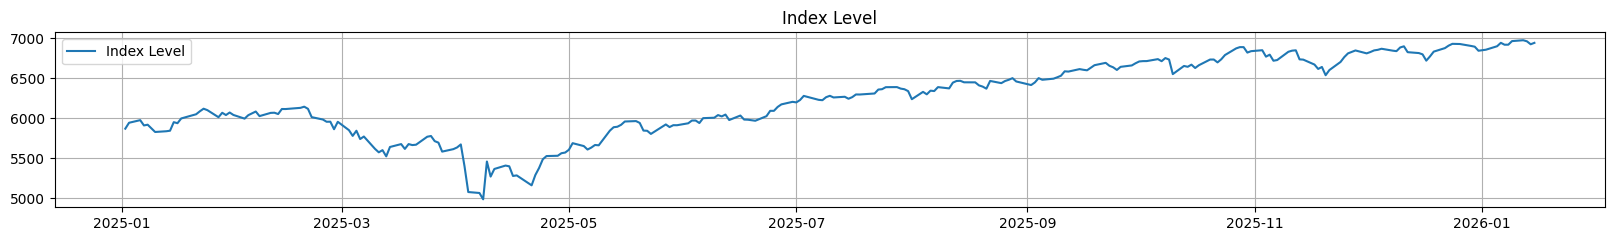

In [78]:
plt.title('Backtesting of Analytical VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['VaR'], color='BLACK', marker='x')
plt.legend(["VaR 99%/10D","return_10D fwd","Breach"])
plt.grid()

fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

## Answer 4.c

Adaptivity Comparison
Among rolling-window volatility, EWMA, and historical simulation:

EWMA exhibits the best adaptivity because it assigns exponentially higher weight to recent returns and updates volatility instantaneously.

Rolling-window volatility has moderate adaptivity due to equal weighting and slow information decay.

Historical simulation shows the worst adaptivity because it does not model time-varying volatility and relies on static past distribution.